## Anàlisi de Correlació: Possessió vs. Mètriques Esportives per Lliga
Aquest notebook analitza la relació entre el percentatge de possessió i diferents variables de rendiment esportiu a les cinc grans lligues europees. L'estudi inclou una anàlisi de correlació de Pearson, una exploració visual mitjançant diagrames de dispersió, l'estudi de la distribució de la possessió dels equips campions de lliga i una comparativa entre la possessió dels campions de les competicions de lliga i els vencedors de competicions UEFA.

Importació de llibreries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from sqlalchemy import create_engine
from connexio import USER, PASSWORD, HOST, PORT, DATABASE
from typing import cast

Configuració estètica general

In [2]:
sns.set_theme(style="whitegrid")

Connexió MySQL

In [3]:
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

Extracció de dades des de MySQL

In [4]:
query = """
SELECT f.*, l.lliga
FROM fact_equip_temporada AS f
INNER JOIN dim_lliga AS l ON f.id_lliga = l.id_lliga;
"""

df_equips = pd.read_sql(query, engine)

Establiment de paleta de colors per a totes les lligues a tots els gràfics

In [5]:
lligues_uniques = sorted(df_equips["lliga"].unique())
paleta_lligues = dict(zip(lligues_uniques, sns.color_palette("tab10", len(lligues_uniques)).as_hex()))
paleta_lligues["GER-Bundesliga"] = "#17becf"

Diccionari d'ordre estricte

In [6]:
df_equips["lliga_guanyada"] = (df_equips["classificacio"] == 1).astype(int)

variables_analisi = {
    "Targetes grogues": "targetes_grogues",
    "Targetes vermelles": "targetes_vermelles",
    "Faltes favor": "faltes_rebudes",
    "Faltes contra": "faltes_comeses",
    "Penals favor": "penals_favor",
    "Penals contra": "penals_contra",
    "Xuts favor": "xuts_realitzats",
    "Xuts contra": "xuts_rebuts",
    "Gols favor": "gols_realitzats",
    "Gols contra": "gols_rebuts",
    "Partits guanyats": "victories",
    "Partits empatats": "empats",
    "Partits perduts": "derrotes"}

Càlcul de la correlació de Pearson

In [ ]:
resultats_per_lliga = []

for nom_lliga, grup in df_equips.groupby("lliga"):
    for variable, columna in variables_analisi.items():
        sub = grup[["possessio", columna]].dropna()
        if len(sub) > 2:
            res = stats.pearsonr(sub["possessio"], sub[columna])

            r = cast(float, res[0])
            p_val = cast(float, res[1])

            resultats_per_lliga.append(
                {   "Lliga": nom_lliga,
                    "Variable": variable,
                    "Correlació Pearson (r)": round(r, 4),
                    "p-valor": round(p_val, 6),
                    "Significatiu (p < 0.05)": "Sí" if p_val < 0.05 else "No"})

df_correlacions = pd.DataFrame(resultats_per_lliga)

## Matriu de correlacions de Pearson (r) entre la possessió i les variables de joc

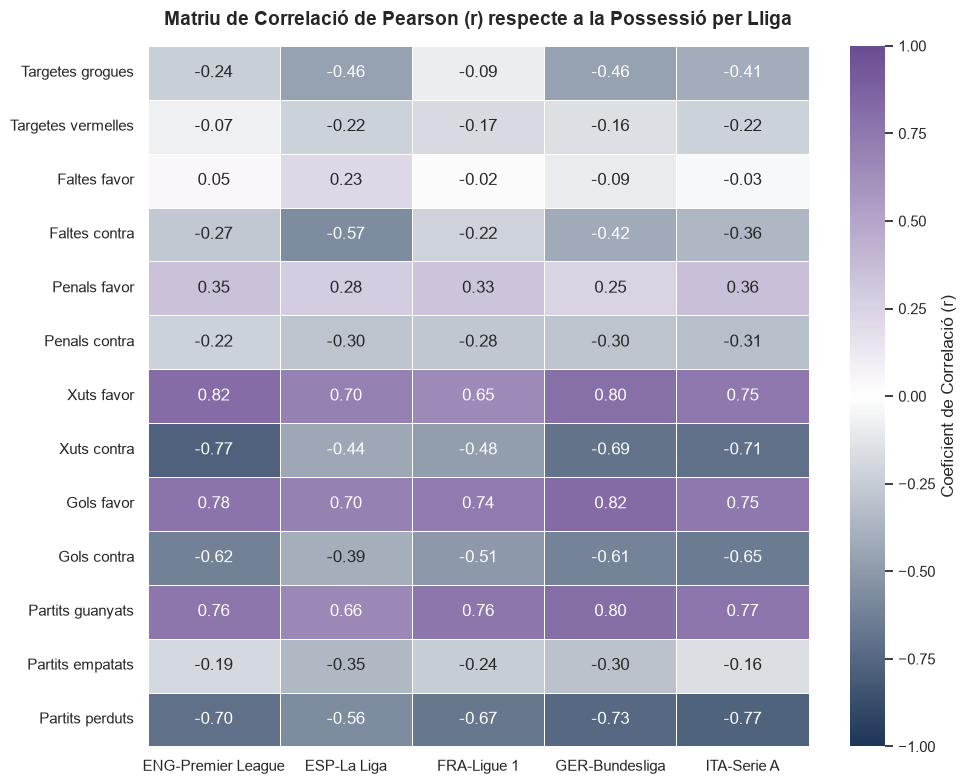

In [26]:
pivot_r = df_correlacions.pivot(index="Variable", columns="Lliga", values="Correlació Pearson (r)")

ordre_y = list(variables_analisi.keys())
pivot_r = pivot_r.reindex(ordre_y)

plt.figure(figsize=(10, 8))
paleta_lila_blau = sns.blend_palette(["#1D3557", "#FFFFFF", "#6A4C93"], as_cmap=True)
sns.heatmap(pivot_r, annot=True, cmap=paleta_lila_blau, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, cbar_kws={"label": "Coeficient de Correlació (r)"})

plt.title("Matriu de Correlació de Pearson (r) respecte a la Possessió per Lliga", fontsize=14, pad=15, fontweight="bold")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Diagrames de dispersió per lliga entre la possessió i les variables de joc

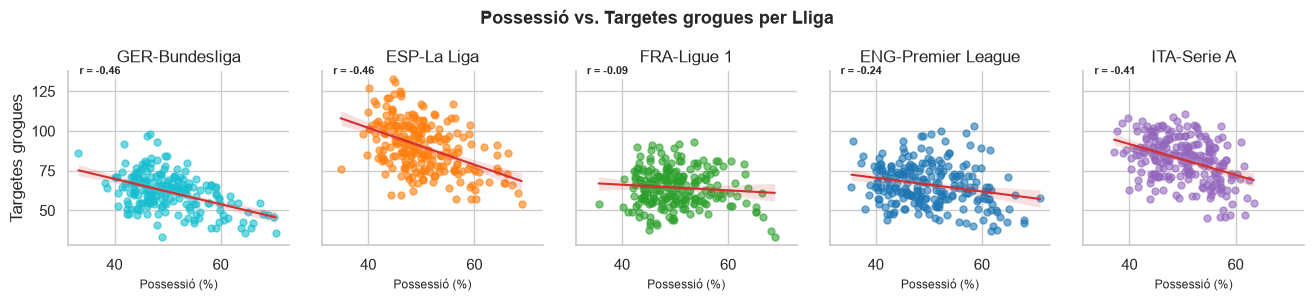

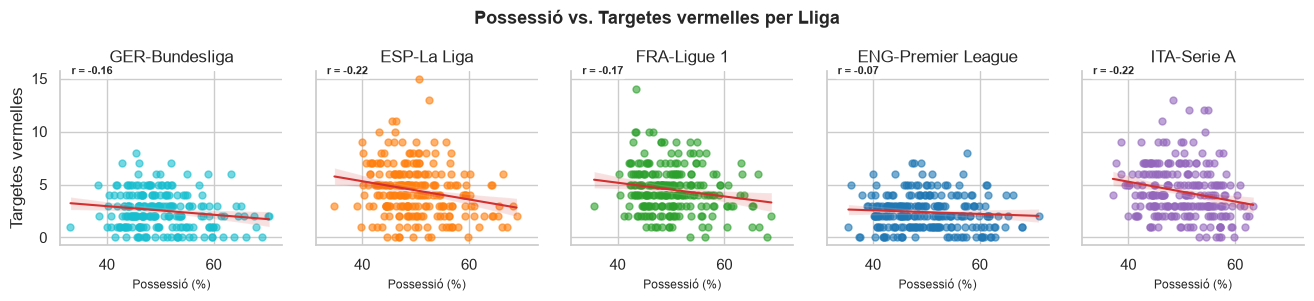

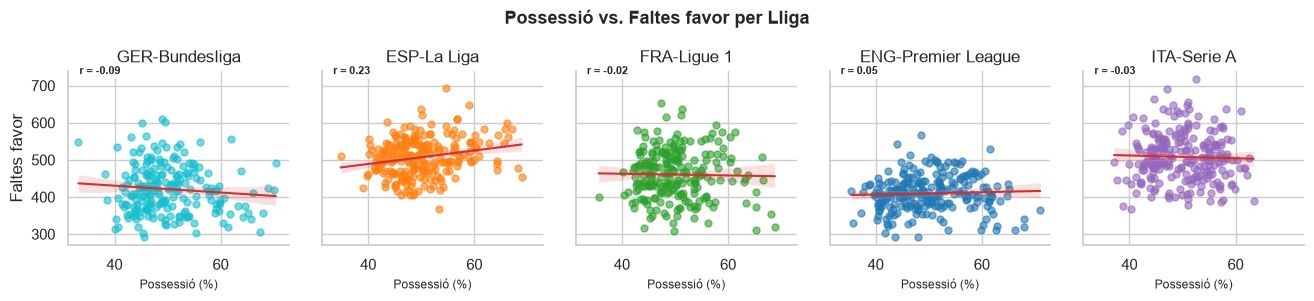

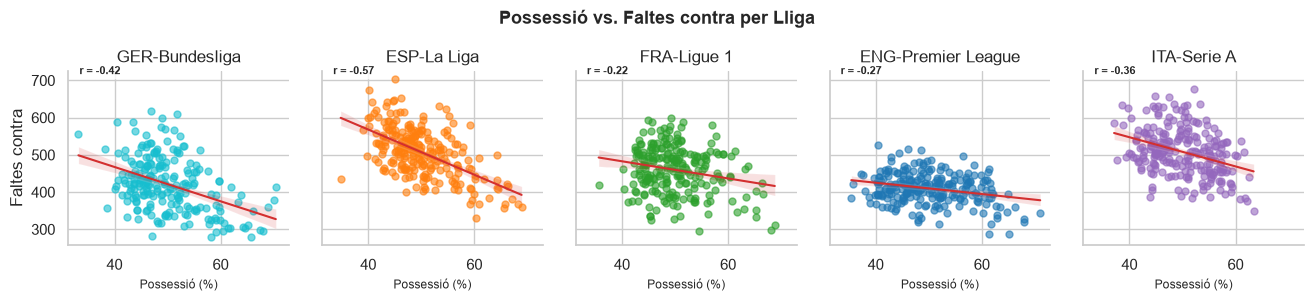

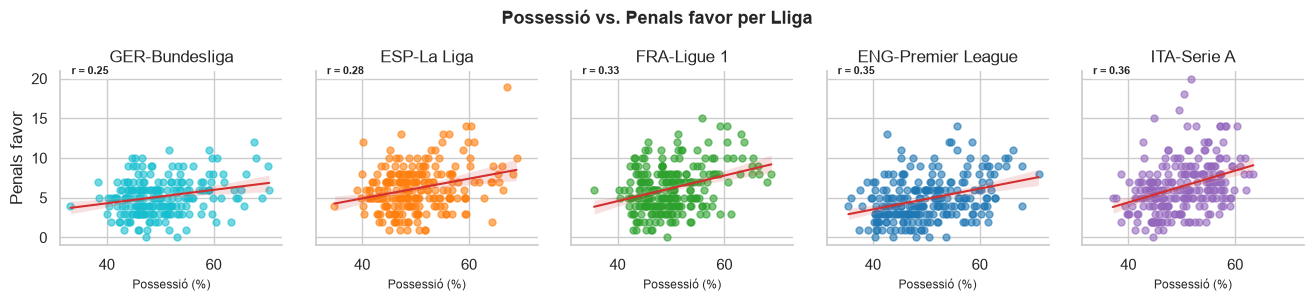

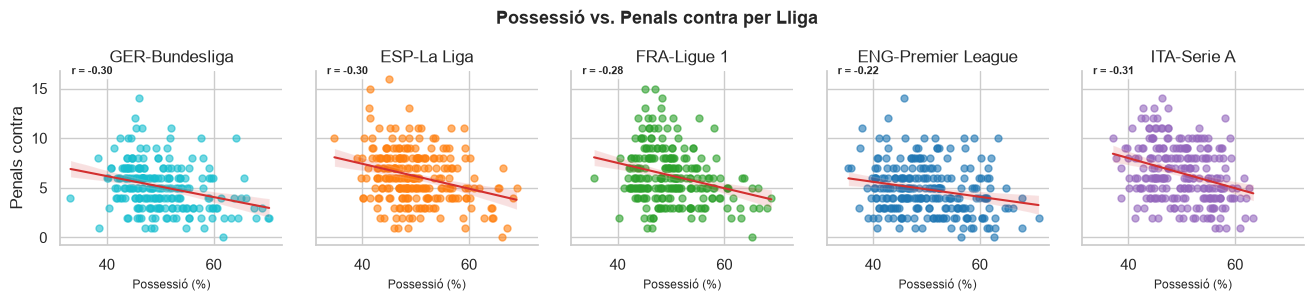

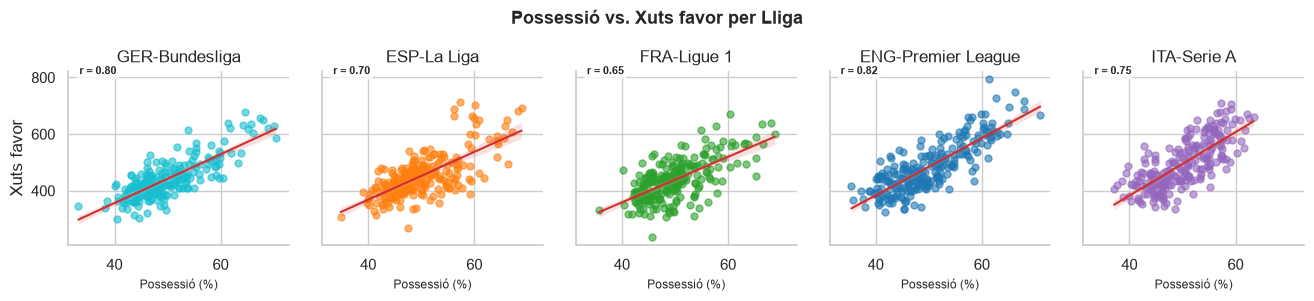

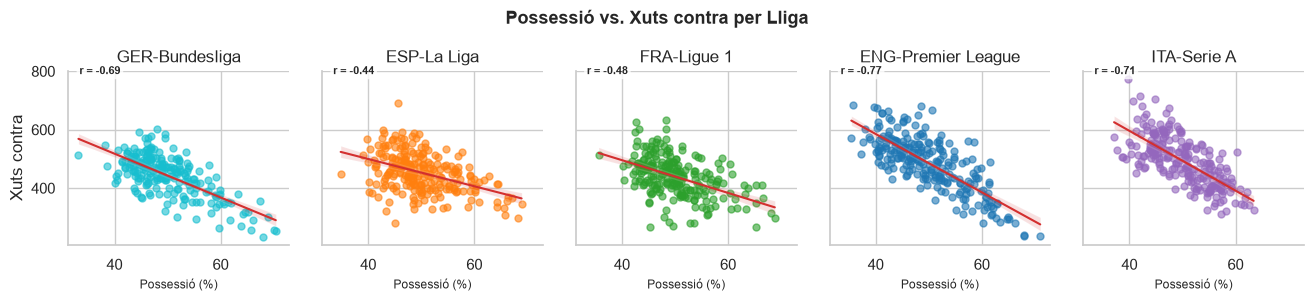

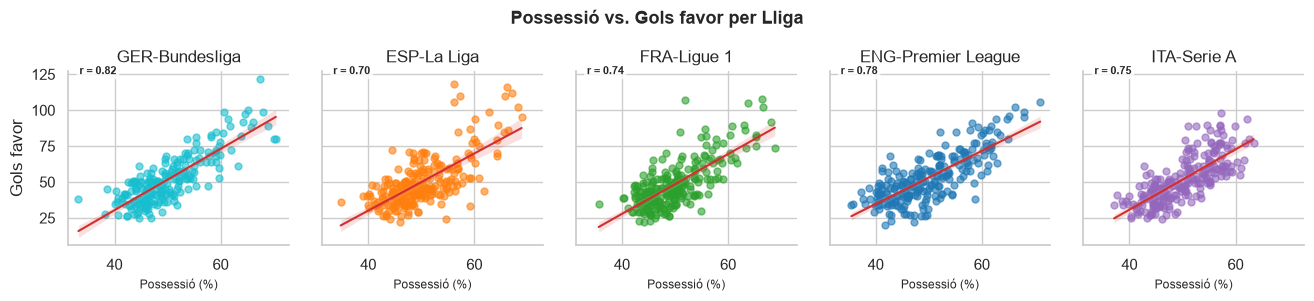

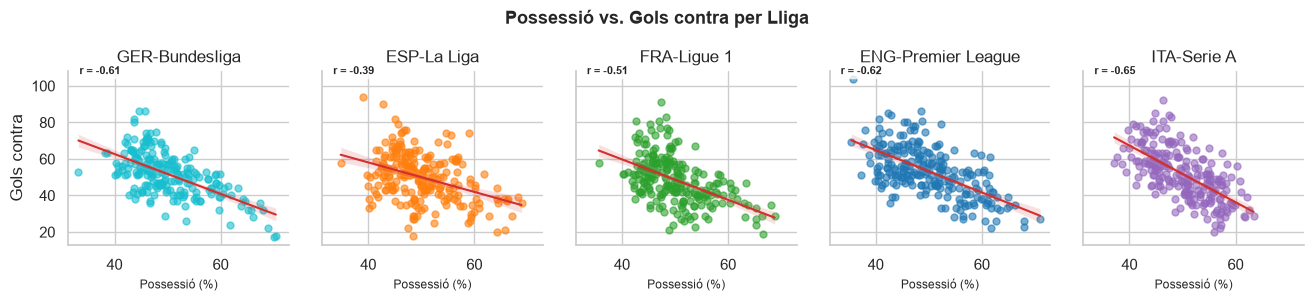

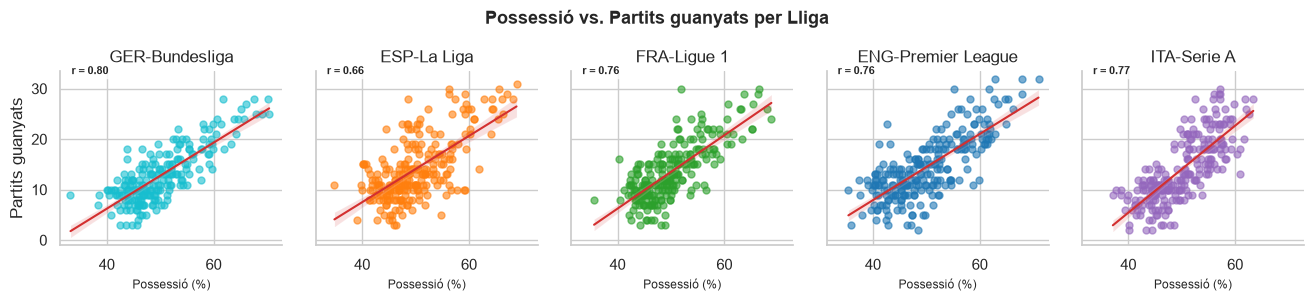

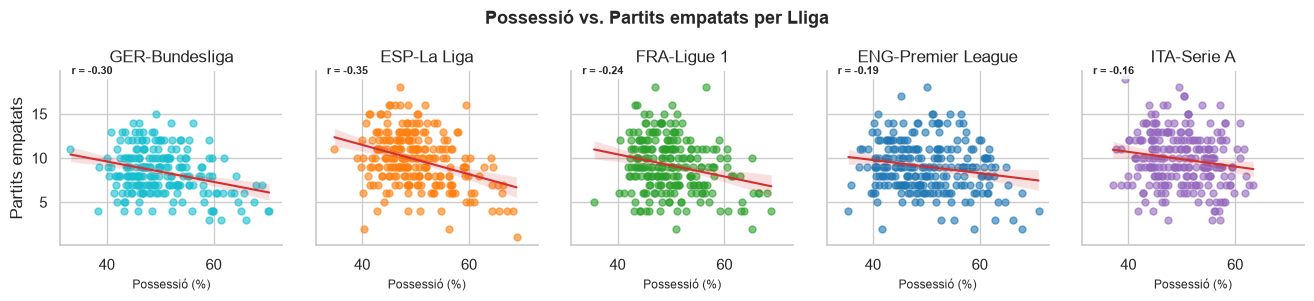

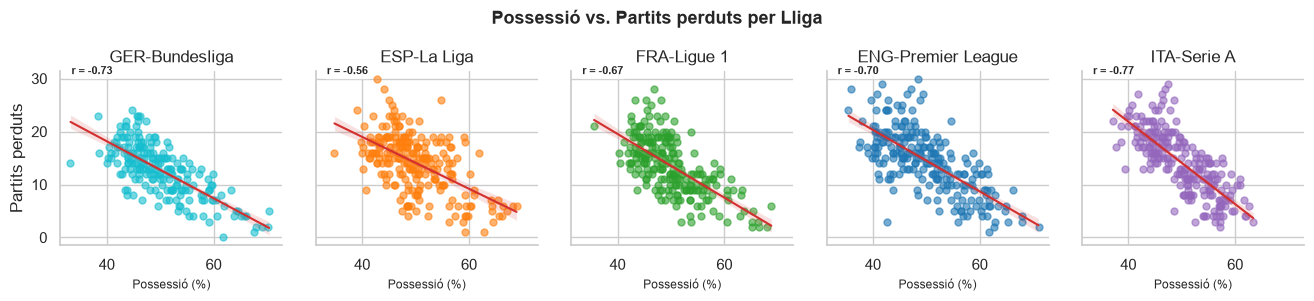

In [ ]:
for nom_var, col in variables_analisi.items():
    g = sns.lmplot(
        data=df_equips,
        x="possessio",
        y=col,
        hue="lliga",
        col="lliga",
        palette=paleta_lligues,
        height=2.8,
        aspect=0.95,
        scatter_kws={"alpha": 0.6, "s": 25},
        line_kws={"color": "#D32F2F","linewidth": 1.5},
        facet_kws={"sharex": True, "sharey": True})

    g.set_titles(col_template="{col_name}")

    g.set_axis_labels("", nom_var)

    for nom_lliga, ax in g.axes_dict.items():
        sub = df_equips[df_equips["lliga"] == nom_lliga][["possessio", col]].dropna()

        if len(sub) > 2:
            r, _ = stats.pearsonr(sub["possessio"], sub[col])

            ax.text(
                0.05,
                0.98,
                f"r = {r:.2f}",
                transform=ax.transAxes,
                fontsize=8.0,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    alpha=0.8,
                    edgecolor="none"))

        ax.tick_params(labelbottom=True)
        ax.set_xlabel("Possessió (%)", fontsize=8.5)

    g.figure.subplots_adjust(wspace=0.15)
    g.figure.suptitle(f"Possessió vs. {nom_var} per Lliga", y=1.08, fontsize=13, fontweight="bold")

    plt.show()

## Distribució de la possessió dels 60 campions de lliga

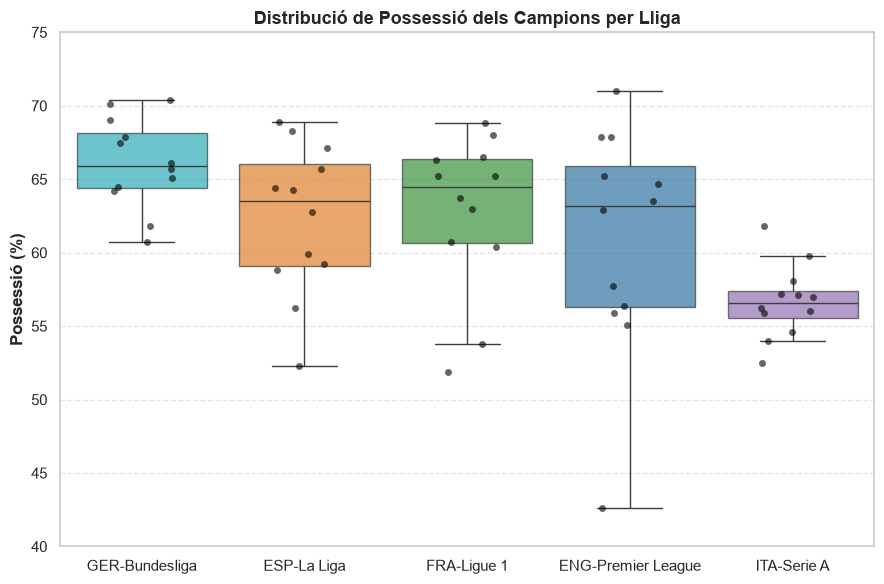

In [28]:
df_campions = df_equips[df_equips["classificacio"] == 1].copy()

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_campions,
    x="lliga",
    y="possessio",
    hue="lliga",
    palette=paleta_lligues,
    legend=False,
    boxprops=dict(alpha=0.7),
    showfliers=False)

sns.stripplot(
    data=df_campions,
    x="lliga",
    y="possessio",
    color="black",
    alpha=0.6,
    size=5,
    jitter=0.2)

plt.title("Distribució de Possessió dels Campions per Lliga", fontweight="bold", fontsize=13)
plt.xlabel("")
plt.ylabel("Possessió (%)", fontweight="bold")
plt.ylim(40, 75)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Comparativa possessio Campions Lliga vs Campions finals UEFA.

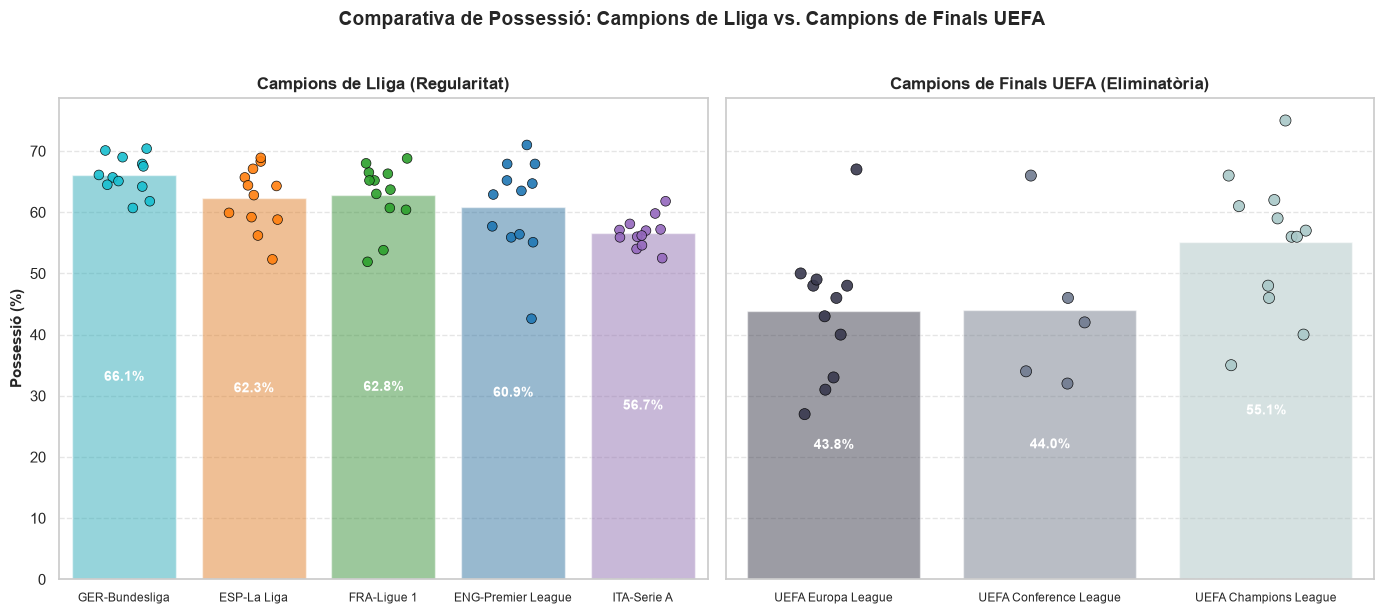

In [ ]:
query_uefa = "SELECT competicio, possessio_guanyador FROM fact_finals_uefa"
campions_uefa = pd.read_sql(query_uefa, engine).dropna(subset=["possessio_guanyador"])

campions_lliga = df_equips[df_equips["classificacio"] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

order_lliga = list(campions_lliga["lliga"].unique())

sns.barplot(
    data=campions_lliga,
    x="lliga",
    y="possessio",
    hue="lliga",
    legend=False,
    order=order_lliga,
    ax=axes[0],
    palette=paleta_lligues,
    alpha=0.5,
    errorbar=None)

sns.stripplot(
    data=campions_lliga,
    x="lliga",
    y="possessio",
    hue="lliga",
    legend=False,
    order=order_lliga,
    ax=axes[0],
    palette=paleta_lligues,
    size=7,
    jitter=0.2,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5)

axes[0].set_title("Campions de Lliga (Regularitat)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Possessió (%)", fontsize=11, fontweight="bold")

axes[0].tick_params(axis="x", rotation=0, labelsize=8.5)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

mitjanes_lliga = campions_lliga.groupby("lliga")["possessio"].mean()
for posicio_x, nom_lliga in enumerate(order_lliga):
    if nom_lliga in mitjanes_lliga:
        val = mitjanes_lliga[nom_lliga]
        axes[0].text(
            posicio_x,
            val / 2,
            f"{val:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=10)


order_uefa = list(campions_uefa["competicio"].unique())

sns.barplot(
    data=campions_uefa,
    x="competicio",
    y="possessio_guanyador",
    hue="competicio",
    legend=False,
    order=order_uefa,
    ax=axes[1],
    palette="bone",
    alpha=0.5,
    errorbar=None)

sns.stripplot(
    data=campions_uefa,
    x="competicio",
    y="possessio_guanyador",
    hue="competicio",
    legend=False,
    order=order_uefa,
    ax=axes[1],
    palette="bone",
    size=8,
    jitter=0.2,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5)

axes[1].set_title("Campions de Finals UEFA (Eliminatòria)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

axes[1].tick_params(axis="x", rotation=0, labelsize=8.5)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

mitjanes_uefa = campions_uefa.groupby("competicio")["possessio_guanyador"].mean()
for posicio_x, nom_competicio in enumerate(order_uefa):
    if nom_competicio in mitjanes_uefa:
        val = mitjanes_uefa[nom_competicio]
        axes[1].text(
            posicio_x,
            val / 2,
            f"{val:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=10)

fig.suptitle("Comparativa de Possessió: Campions de Lliga vs. Campions de Finals UEFA", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()